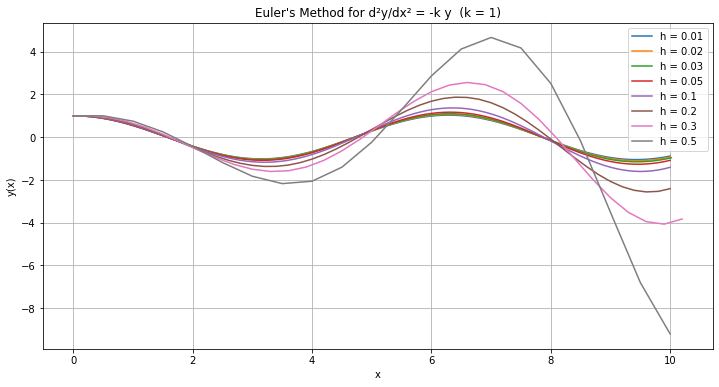

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------
# Function to run Euler's Method
# ---------------------------------------
def euler_oscillator(k, h, x_end=10, y0=1.0, v0=0.0):
    x_values = np.arange(0, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    y_values[0] = y0
    v_values[0] = v0

    for i in range(1, len(x_values)):
        y_n = y_values[i-1]
        v_n = v_values[i-1]

        # Euler updates
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)

    return x_values, y_values, v_values


# ---------------------------------------
# Step sizes to test
# ---------------------------------------
h_values = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]
k = 1.0   # baseline spring constant

plt.figure(figsize=(12, 6))

for h in h_values:
    x, y, v = euler_oscillator(k, h)
    plt.plot(x, y, label=f"h = {h}")

plt.title("Euler's Method for d²y/dx² = -k y  (k = 1)")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.grid(True)
plt.legend()
plt.show()

# Stability Exploration: Play with K

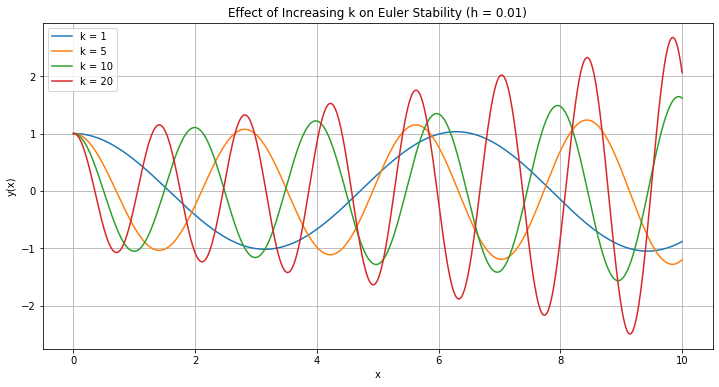

In [3]:
# Try different values of k
k_values = [1, 5, 10, 20]
h = 0.01

plt.figure(figsize=(12, 6))

for k in k_values:
    x, y, v = euler_oscillator(k, h)
    plt.plot(x, y, label=f"k = {k}")

plt.title("Effect of Increasing k on Euler Stability (h = 0.01)")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.grid(True)
plt.legend()
plt.show()

# Special Case: k = 10, h = 0.01

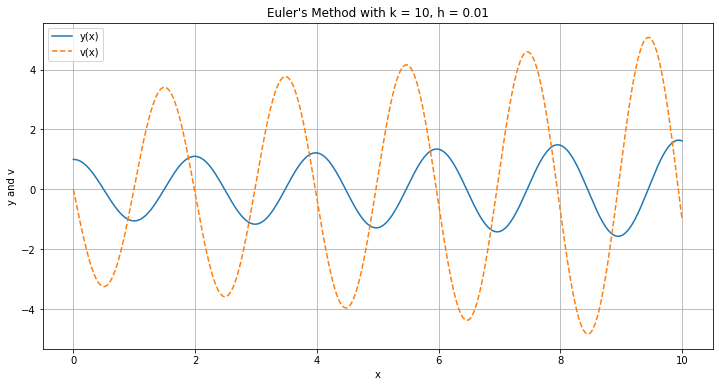

In [4]:
k = 10
h = 0.01

x, y, v = euler_oscillator(k, h)

plt.figure(figsize=(12, 6))
plt.plot(x, y, label="y(x)")
plt.plot(x, v, label="v(x)", linestyle="--")
plt.title("Euler's Method with k = 10, h = 0.01")
plt.xlabel("x")
plt.ylabel("y and v")
plt.grid(True)
plt.legend()
plt.show()

Euler’s Method works fine when the step size h is small. As h gets bigger, the oscillations start growing in height even though they shouldn’t. That’s the point where it becomes unstable. So yes, it is becoming unstable, the increasing amplitude is the giveaway.

When you increase k, the system oscillates faster, which means Euler needs an even smaller h. If you keep h the same and make k bigger, the method becomes unstable sooner.

For k=10 and h=0.01, the solution still looks okay, but the amplitude slowly grows. It’s barely stable.

Euler’s Method can’t handle larger h for this kind of problem. It adds energy every step, so bigger step sizes make it blow up quickly.